In [1]:
import matplotlib.pyplot as plt # For ploting field
import numpy as np
import json
import sys

sys.path.append("../../..")
import larp # Our tool [pip install Larp]
import larp.io as lpio

from_crs_requests = "WGS84"
from_crs_map = "urn:ogc:def:crs:OGC:1.3:CRS84"
to_crs = "EPSG:3857"

# ---- Required Data ------
requests_file_path = "docs/demos/Routes for Austin TX/example_requests.json" # JSON with origins ('point1') and destinations ('point2') with bounding box of service area
requests_file_path = "../../../.rug_routes0.json" # JSON with origins ('point1') and destinations ('point2') with bounding box of service area
map_geojson_file_path = "path/to/austin_downtown.geojson" # Download from OpenStreetMap and convert GeoJSON (Building Only)
map_geojson_file_path = "../../../.rug_larp_features.geojson" # Download from OpenStreetMap (Building Only)

edges = [0.01, 0.2, 0.4, 0.6, 0.8]

def progress_bar(percentage, size=100, end=False):
    # https://gist.github.com/wzjoriv/4906a6722805f2d1194a40ddfd158642
    count = int(percentage*size)
    percentage_int = int(percentage*100)
    print(f"({percentage_int:3d}%)[{'|'*count+' '*(size-count)}]", end="\n" if percentage == 1.0 or end else "\r")

## Load requests

In [2]:
# load origin and destinations
with open(requests_file_path) as file:
    requestsF = json.load(file)

# Project coordinates to meters
## Project bounding box
requestsF['boundingbox'] = larp.project_points(requestsF['boundingbox'], from_crs=from_crs_requests, to_crs=to_crs)

## Project origin and destination of routes
locations = []
for i in range(len(requestsF['routes'])):
    for j in range(len(requestsF['routes'][i])):
        locations.append(requestsF['routes'][i][j]['point1'])
        locations.append(requestsF['routes'][i][j]['point2'])

locations = larp.project_points(locations, from_crs=from_crs_requests, to_crs=to_crs)
starts = locations[::2]
ends = locations[1::2]

## Load potential field

In [3]:
# Load potential field for Austin
field = lpio.loadGeoJSONFile(map_geojson_file_path)
lpio.projectCoordinates(field, from_crs=from_crs_map, to_crs=to_crs)
field.set_all_repulsion([[100.0, 0.0], [0.0, 100.0]]) # strength of repulsion from building (higher = consider greater push away from buildings)

## Display potential field

In [4]:
qfield = larp.QPotentailField(field) # temporary qfield for fast image drawing

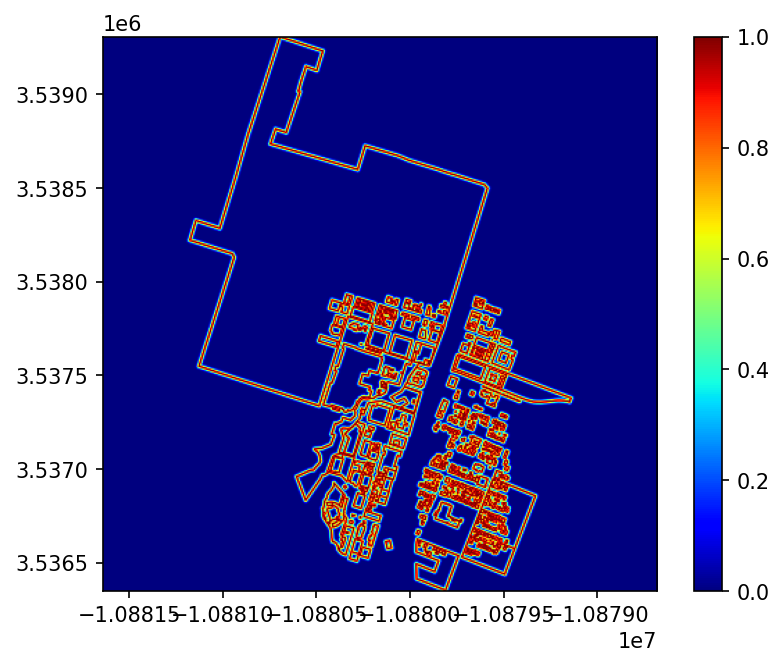

In [5]:
margin = 0.0
display, extent = qfield.to_image(resolution=400, margin=margin, max_depth=4)
plt.figure(dpi=150)
plt.imshow(display, cmap='jet', extent=extent)
plt.colorbar()
plt.clim(0.0,1.0)
plt.show()

## Cell decomposition and routing network

In [6]:
quadtree = larp.quad.QuadTree(qfield, minimum_length_limit=5, maximum_length_limit=50, edge_bounds=edges, build_tree=True)

In [7]:
planner = larp.pp.QuadPlanner(quadtree)
qfield = larp.QPotentailField(quadtree) # To add and remove rgjs (units) and updating quadtree and networks using hot reloading

## Search routes

In [8]:
def rgj_bbox(point):
    point_rgjs = qfield.find_bbox(point)

    if len(point_rgjs) == 0:
        return []
    
    _, reference = qfield.squared_dist([point], filted_idx=point_rgjs, return_reference=True)

    return reference

In [9]:
k = 1.1 # sensitivity to potential from buildings (lower = less senstative)

routes_quad = []
print("Routes searched:")
progress_bar(0.0)

n = len(starts) # number of routes to search from origin (starts) and destinations (ends) pairs

for i in range(n):

    locations_rgj = rgj_bbox(starts[i]) + rgj_bbox(ends[i])

    if len(locations_rgj): dropped_field:larp.PotentialField = qfield.delRGJ(locations_rgj, pop_field=True)
    planner.refresh_network()
    routes_quad.append(planner.find_path(starts[i], ends[i], scaler=lambda p: 1000*p+1, alg='A*'))
    if len(locations_rgj): qfield.addField(dropped_field)
    
    progress_bar((i+1.0)/n)

Routes searched:
(100%)[||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||]


In [14]:
routes_xy = []
for start, end, route in zip(starts, ends, routes_quad):

    path, path_quad = route

    if path is None:
        routes_xy.append(None)
        # print(f"Failed Route Search: Start ({start.tolist()}) End ({end.tolist()})")
    else:
        routes_xy.append(path)

print("Route Found:")
progress_bar(sum([val is not None for val in routes_xy])/float(len(routes_xy)), end=True)        

Route Found:
(  1%)[|                                                                                                   ]


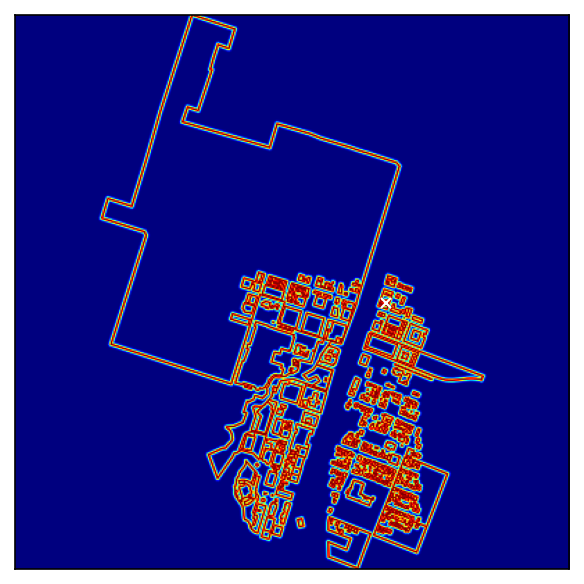

In [13]:
plt.figure(dpi=150)
plt.imshow(display, cmap='jet', extent=extent)
plt.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False) 

for i in range(n):
    if routes_xy[i] is None:
        continue 
    route_path = np.array(routes_xy[i])
    plt.plot(route_path[:, 0], route_path[:, 1], color="#eee", alpha=1.0, linewidth=1.0)
    plt.plot(route_path[-1, 0], route_path[-1, 1], 'wx', markersize=5.0)
# plt.colorbar()
plt.clim(0.0,1.0)
plt.show()